Run 1/1500 complete.
Run 2/1500 complete.
Run 3/1500 complete.
Run 4/1500 complete.
Run 5/1500 complete.
Run 6/1500 complete.
Run 7/1500 complete.
Run 8/1500 complete.
Run 9/1500 complete.
Run 10/1500 complete.
Run 11/1500 complete.
Run 12/1500 complete.
Run 13/1500 complete.
Run 14/1500 complete.
Run 15/1500 complete.
Run 16/1500 complete.
Run 17/1500 complete.
Run 18/1500 complete.
Run 19/1500 complete.
Run 20/1500 complete.
Run 21/1500 complete.
Run 22/1500 complete.
Run 23/1500 complete.
Run 24/1500 complete.
Run 25/1500 complete.
Run 26/1500 complete.
Run 27/1500 complete.
Run 28/1500 complete.
Run 29/1500 complete.
Run 30/1500 complete.
Run 31/1500 complete.
Run 32/1500 complete.
Run 33/1500 complete.
Run 34/1500 complete.
Run 35/1500 complete.
Run 36/1500 complete.
Run 37/1500 complete.
Run 38/1500 complete.
Run 39/1500 complete.
Run 40/1500 complete.
Run 41/1500 complete.
Run 42/1500 complete.
Run 43/1500 complete.
Run 44/1500 complete.
Run 45/1500 complete.
Run 46/1500 complet

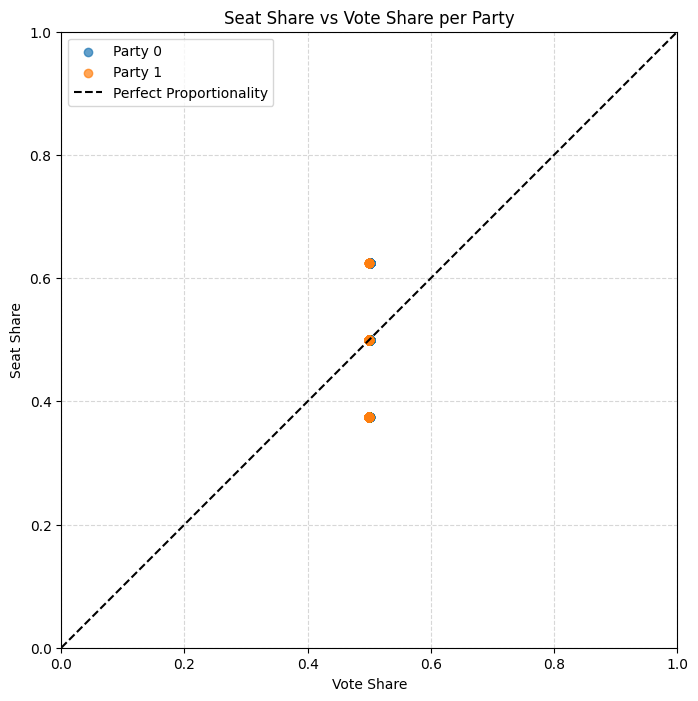


----- REDISTRICTING SUMMARY -----
Runs: 1500
Mean Efficiency Gap: -0.026445333333333328
Std Efficiency Gap: 0.2207755881996216
Party 0: Mean Vote Share = 0.501, Mean Seat Share = 0.547
Party 1: Mean Vote Share = 0.499, Mean Seat Share = 0.453


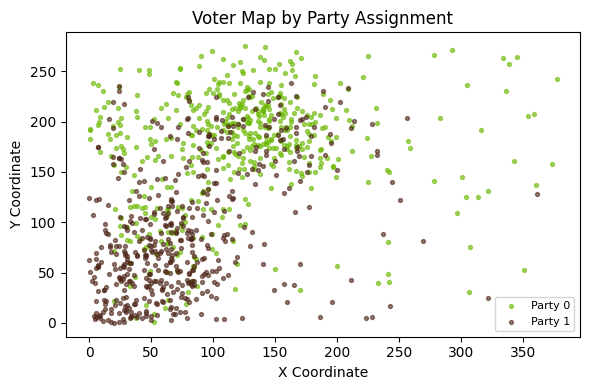

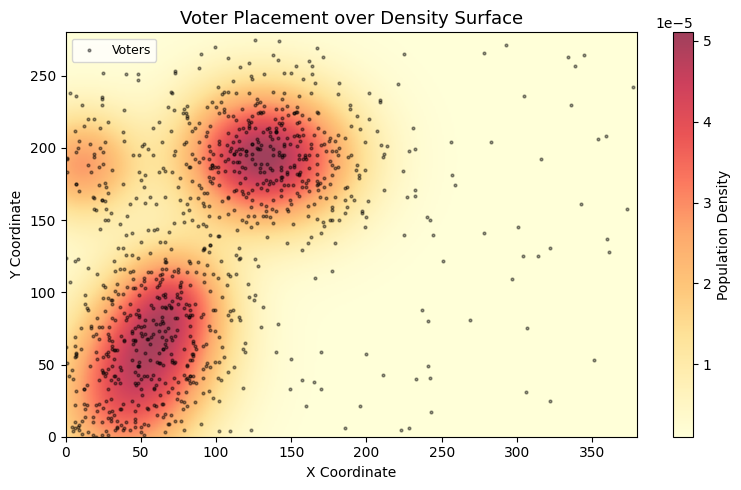

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import itertools
import pandas as pd

# ============================================================
# PARAMETERS
# ============================================================
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 1000
NUM_PARTIES = 2
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 1500

NUM_CITIES = 6
CITY_INTENSITY = (15, 40)
CITY_SPREAD = (15, 35)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

PARTY_BIAS = [0.60, 0.40]

# ============================================================
# GENERATE POPULATION DENSITY
# ============================================================
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ============================================================
# GENERATE VOTERS BASED ON DENSITY
# ============================================================
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ============================================================
# SPATIALLY CORRELATED PARTY PREFERENCES
# ============================================================

# Fixed seed for party centers so the map looks the same every run
np.random.seed(99)
party_centers = np.column_stack((
    np.random.uniform(0, WIDTH,  NUM_PARTIES),
    np.random.uniform(0, HEIGHT, NUM_PARTIES)
))
np.random.seed(1)  # restore main seed

voter_parties = np.zeros(NUM_VOTERS, dtype=int)

for i in range(NUM_VOTERS):
    dists   = np.linalg.norm(party_centers - voters[i], axis=1)
    sigma   = 115
    weights = np.exp(-dists**2 / (2 * sigma**2))
    weights = weights * np.array(PARTY_BIAS)
    weights /= weights.sum()
    voter_parties[i] = np.random.choice(NUM_PARTIES, p=weights)

voter_colors = party_colors[voter_parties]
# ============================================================
# DISTRICT GENERATION
# ============================================================

def connected_districts(voters, num_districts, voters_per_district, rng, k_neighbors=15):
    """
    Builds connected districts using BFS from random seeds.
    Retries automatically if a district cannot be completed.
    """
    N = len(voters)
    district = -np.ones(N, dtype=int)
    tree = cKDTree(voters)
    unassigned = set(range(N))

    for d in range(num_districts):
        if not unassigned:
            break

        seed = list(unassigned)[rng.integers(len(unassigned))]
        district[seed] = d
        unassigned.remove(seed)
        queue = [seed]
        count = 1

        while queue and count < voters_per_district:
            current = queue.pop(0)
            _, neighbors = tree.query(voters[current], k=k_neighbors)
            neighbors = rng.permutation(neighbors)

            for n in neighbors:
                if n in unassigned:
                    district[n] = d
                    unassigned.remove(n)
                    queue.append(n)
                    count += 1
                    if count >= voters_per_district:
                        break

        if count < voters_per_district:
            for i in range(N):
                if district[i] == d:
                    district[i] = -1
                    unassigned.add(i)
            return connected_districts(voters, num_districts, voters_per_district, rng, k_neighbors)

    leftover_indices = np.where(district == -1)[0]
    assigned_indices = np.where(district != -1)[0]

    if len(leftover_indices) > 0:
        assigned_tree = cKDTree(voters[assigned_indices])
        for i in leftover_indices:
            _, idx = assigned_tree.query(voters[i])
            nearest_assigned = assigned_indices[idx]
            district[i] = district[nearest_assigned]

    return district

# ============================================================
# VOTE COUNTING
# ============================================================

def count_votes(district_labels):
    """Returns a list of vote count dicts, one per district."""
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts

# ============================================================
# EFFICIENCY GAP
# ============================================================

def efficiency_gap(district_counts):
    """
    Returns a per-district efficiency gap value (multi-party generalization).
    """
    district_gaps = []
    for district in district_counts:
        winning_party = max(district.items(), key=lambda item: item[1])[0]
        num_winning_votes = district[winning_party]
        total_votes = sum(district.values())
        num_losing_votes = total_votes - num_winning_votes
        wasted_winner = num_winning_votes - (total_votes / NUM_PARTIES)
        wasted_loser = num_losing_votes
        gap = (wasted_winner - wasted_loser) / total_votes
        district_gaps.append(gap)
    return district_gaps

# ============================================================
# SEAT-VOTE CURVE HELPERS
# ============================================================

def get_is_winner(district_counts, target_party):
    """Returns True if target_party strictly leads all others."""
    target_votes = district_counts[target_party]
    other_votes = [district_counts[p] for p in district_counts if p != target_party]
    return all(target_votes > v for v in other_votes)


def get_current_vote_share(district_counts, target_party):
    """Returns the statewide vote share of the target party."""
    total = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total


def simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    """
    Shifts votes toward target_party by taking from the weakest competitor
    in each district, one step at a time.
    """
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            active_competitors = sorted(
                [p for p in competitors if d[p] > 0],
                key=lambda p: (d[p], p)
            )
            if active_competitors:
                from_party = active_competitors[0]
                actual_taken = min(d[from_party], num_competitors)
                if actual_taken > 0:
                    d[from_party] -= actual_taken
                    d[target_party] += actual_taken
                    any_shift = True

        new_wins = count_wins()
        if new_wins > current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == NUM_DISTRICTS:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


def simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS):
    """
    Shifts votes away from target_party toward the strongest competitor
    in each district, one step at a time.
    """
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            ranked_competitors = sorted(
                competitors,
                key=lambda p: (d[p], p),
                reverse=True
            )
            strongest_competitor = ranked_competitors[0]
            to_move = min(d[target_party], num_competitors)
            if to_move > 0:
                d[target_party] -= to_move
                d[strongest_competitor] += to_move
                any_shift = True

        new_wins = count_wins()
        if new_wins < current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == 0:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


def compute_step_curve_for_party(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    """
    Builds the full seat-vote step curve for a given party by merging
    forward and backward vote shift histories.
    """
    initial_vote = get_current_vote_share(district_counts, target_party)
    initial_wins = sum(1 for d in district_counts if get_is_winner(d, target_party))

    fwd = simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS)
    rev = simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS)

    base_point = (initial_vote, initial_wins)
    fwd_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in fwd["history"]]
    rev_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in rev["history"]]

    merged = sorted(set(fwd_points + rev_points))
    return merged

# ============================================================
# PLOTTING
# ============================================================

def plot_step_and_complement(step_points, NUM_DISTRICTS, title="Seat-Vote Curve"):
    """Plots the seat-vote curve and its complement."""
    x, y = zip(*sorted(step_points))
    x, y = np.array(x), np.array(y)
    y = y / NUM_DISTRICTS

    plt.figure(figsize=(8, 6))
    plt.step(x, y, where="post", color="black", label="Seat-Vote Curve", lw=2)

    xc = 1 - x
    yc = 1 - y
    order = np.argsort(xc)
    plt.step(xc[order], yc[order], where="post",
             color="blue", linestyle="--", label="Complement Curve")

    plt.xlabel("Statewide Vote Share")
    plt.ylabel("Seat Share")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()

# ============================================================
# AREA METRICS
# ============================================================

def compute_step_function_area(step_points, num_districts):
    """
    Computes the geometric area between the seat-vote curve and its complement.
    Returns dict with keys: area_between, area_step, area_complement
    """
    points = sorted(step_points, key=lambda x: x[0])

    if points[0][0] > 0:
        points = [(0, 0)] + points
    if points[-1][0] < 1.0:
        points = points + [(1.0, points[-1][1])]

    step_x, step_y = zip(*points)
    step_x = np.array(step_x)
    step_y = np.array(step_y) / num_districts

    complement_x = 1 - step_x[::-1]
    complement_y = 1 - step_y[::-1]

    all_x = np.unique(np.concatenate([step_x, complement_x]))

    area_between = 0.0
    area_step = 0.0
    area_complement = 0.0

    def step_value_at(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    for i in range(len(all_x) - 1):
        x1, x2 = all_x[i], all_x[i + 1]
        width = x2 - x1
        midpoint = (x1 + x2) / 2
        f_val = step_value_at(midpoint, step_x, step_y)
        g_val = step_value_at(midpoint, complement_x, complement_y)
        area_between += width * abs(f_val - g_val)
        area_step += width * f_val
        area_complement += width * g_val

    return {
        "area_between": area_between,
        "area_step": area_step,
        "area_complement": area_complement
    }


def compute_pairwise_area(curve1, curve2, num_districts):
    """
    Computes the absolute area between the step curves of two parties.
    Integral of |f(x) - g(x)| dx over [0, 1].
    """
    x1, y1 = zip(*sorted(curve1))
    x2, y2 = zip(*sorted(curve2))

    y1 = np.array(y1) / num_districts
    y2 = np.array(y2) / num_districts

    all_x = np.unique(np.concatenate([x1, x2]))
    if all_x[0] > 0:
        all_x = np.insert(all_x, 0, 0.0)
    if all_x[-1] < 1:
        all_x = np.append(all_x, 1.0)

    def get_val(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    total_area = 0.0
    for i in range(len(all_x) - 1):
        mid = (all_x[i] + all_x[i+1]) / 2
        width = all_x[i+1] - all_x[i]
        diff = abs(get_val(mid, x1, y1) - get_val(mid, x2, y2))
        total_area += width * diff

    return total_area

# ============================================================
# EXCEL EXPORT
# ============================================================

def export_full_simulation_data(all_district_counts, all_step_curves, PARTY_IDS,
                                 filename="gerrymandering_data.xlsx"):
    """
    Exports simulation results to Excel with four sheets:
      - District_Details: per-district vote counts and winners
      - Pairwise_Areas:   area gap between each party pair per run
      - Efficiency_Gaps:  efficiency gap per party per run
      - Summary:          mean and std of pairwise areas
    """
    print(f"Gathering data for {len(all_district_counts)} runs...")

    dist_rows = []
    for run_idx, run_counts in enumerate(all_district_counts):
        for dist_idx, counts in enumerate(run_counts):
            winner = max(counts, key=counts.get)
            row = {"Run": run_idx + 1, "District": dist_idx + 1, "Winner": winner}
            for party in PARTY_IDS:
                row[f"{party}_Votes"] = counts[party]
            dist_rows.append(row)
    df_districts = pd.DataFrame(dist_rows)

    pair_rows = []
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    for run_idx in range(len(all_step_curves)):
        current_curves = all_step_curves[run_idx]
        for p1, p2 in party_pairs:
            gap = compute_pairwise_area(current_curves[p1], current_curves[p2], NUM_DISTRICTS)
            pair_rows.append({"Run": run_idx + 1, "Comparison": f"{p1} vs {p2}", "Area_Gap": gap})
    df_areas = pd.DataFrame(pair_rows)

    gap_rows = []
    for run_idx, district_counts in enumerate(all_district_counts):
        wasted_votes = {p: 0 for p in PARTY_IDS}
        total_v = 0
        for d in district_counts:
            d_total = sum(d.values())
            total_v += d_total
            sorted_v = sorted(d.values(), reverse=True)
            winner_p = max(d, key=d.get)
            needed = sorted_v[1] + 1 if len(sorted_v) > 1 else (d_total // 2) + 1
            for p in PARTY_IDS:
                wasted_votes[p] += (max(0, d[p] - needed) if p == winner_p else d[p])
        for p in PARTY_IDS:
            others = sum(v for k, v in wasted_votes.items() if k != p)
            gap_rows.append({
                "Run": run_idx + 1,
                "Party": p,
                "Eff_Gap": (wasted_votes[p] - others) / total_v
            })
    df_eff = pd.DataFrame(gap_rows)

    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        df_districts.to_excel(writer, sheet_name='District_Details', index=False)
        df_areas.to_excel(writer, sheet_name='Pairwise_Areas', index=False)
        df_eff.to_excel(writer, sheet_name='Efficiency_Gaps', index=False)
        summary = df_areas.groupby("Comparison")["Area_Gap"].agg(['mean', 'std']).reset_index()
        summary.to_excel(writer, sheet_name='Summary', index=False)

    print(f"Export Complete: {filename}")

# ============================================================
# MAIN SIMULATION
# ============================================================

all_efficiency_gaps = []
all_seat_counts = []
all_vote_shares = []
all_seat_shares = []
all_pr_vote_shares = []
all_pr_seat_shares = []
all_district_counts = []
all_area_results = []
all_step_curves = []

for run in range(NUM_RUNS):
    rng = np.random.default_rng(run)

    district_labels = connected_districts(
        voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT, rng
    )
    district_counts = count_votes(district_labels)

    gap = efficiency_gap(district_counts)
    all_efficiency_gaps.append(gap)

    pr_vote_share = {party: 0 for party in PARTY_IDS}
    pr_seat_share = {party: 0 for party in PARTY_IDS}

    for d in district_counts:
        for party in PARTY_IDS:
            pr_vote_share[party] += d[party]

    total_votes = sum(pr_vote_share.values())
    for party in PARTY_IDS:
        pr_vote_share[party] /= total_votes

    for d in district_counts:
        winner = max(d, key=d.get)
        pr_seat_share[winner] += 1
    for party in PARTY_IDS:
        pr_seat_share[party] /= NUM_DISTRICTS

    all_pr_vote_shares.append(pr_vote_share)
    all_pr_seat_shares.append(pr_seat_share)
    all_district_counts.append(district_counts)

    step_curves_this_run = {}
    area_results_this_run = {}

    for party in PARTY_IDS:
        curve = compute_step_curve_for_party(
            district_counts, party, PARTY_IDS, NUM_DISTRICTS
        )
        step_curves_this_run[party] = curve
        area_results_this_run[party] = compute_step_function_area(curve, NUM_DISTRICTS)

    all_step_curves.append(step_curves_this_run)
    all_area_results.append(area_results_this_run)

    print(f"Run {run + 1}/{NUM_RUNS} complete.")

# ============================================================
# SCATTER PLOT: Vote Share vs Seat Share
# ============================================================

plt.figure(figsize=(8, 8))
for party in PARTY_IDS:
    vote_shares = [run[party] for run in all_pr_vote_shares]
    seat_shares = [run[party] for run in all_pr_seat_shares]
    plt.scatter(vote_shares, seat_shares, alpha=0.7, label=party)

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Proportionality')
plt.xlabel("Vote Share")
plt.ylabel("Seat Share")
plt.title("Seat Share vs Vote Share per Party")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ============================================================
# SUMMARY
# ============================================================

print("\n----- REDISTRICTING SUMMARY -----")
print("Runs:", NUM_RUNS)
if NUM_PARTIES == 2:
    print("Mean Efficiency Gap:", np.nanmean(all_efficiency_gaps))
    print("Std Efficiency Gap:", np.nanstd(all_efficiency_gaps))
for party in PARTY_IDS:
    mean_vote = np.mean([run[party] for run in all_pr_vote_shares])
    mean_seat = np.mean([run[party] for run in all_pr_seat_shares])
    print(f"{party}: Mean Vote Share = {mean_vote:.3f}, Mean Seat Share = {mean_seat:.3f}")


plt.figure(figsize=(6, 4))
for i, party in enumerate(PARTY_IDS):
    mask = voter_parties == i
    plt.scatter(voters[mask, 0], voters[mask, 1],
                color=PARTY_COLORS[party], label=party, s=8, alpha=0.6)
plt.title("Voter Map by Party Assignment")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("voter_map_by_party.png", dpi=150)
plt.show()


plt.figure(figsize=(8, 5))
plt.imshow(
    density,
    origin='lower',
    cmap='YlOrRd',
    extent=[0, WIDTH, 0, HEIGHT],
    aspect='auto',
    alpha=0.75
)
cbar = plt.colorbar()
cbar.set_label("Population Density", fontsize=10)
plt.scatter(
    voters[:, 0], voters[:, 1],
    s=4, color='black', alpha=0.4, label='Voters'
)
plt.title("Voter Placement over Density Surface", fontsize=13)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("density_with_voters.png", dpi=150)
plt.show()

In [66]:
# ------------------------------------------------------------
# RUN PAIRWISE SIMULATIONS
# ------------------------------------------------------------
pairwise_results = []
party_pairs = list(itertools.combinations(PARTY_IDS, 2))

for run_idx in range(NUM_RUNS):
    # (Assuming district_counts and curves are generated here as in your main code)
    # Get all party curves for this run
    current_curves = all_step_curves[run_idx] 
    
    for p1, p2 in party_pairs:
        area_gap = compute_pairwise_area(current_curves[p1], current_curves[p2], NUM_DISTRICTS)
        
        pairwise_results.append({
            "Run": run_idx + 1,
            "Comparison": f"{p1} vs {p2}",
            "Area Gap": area_gap
        })

df_pairs = pd.DataFrame(pairwise_results)
print("\n--- PAIRWISE AREA DIFFERENCES ---")
print(df_pairs.head(20).to_string(index=False))



--- PAIRWISE AREA DIFFERENCES ---
 Run         Comparison  Area Gap
   1 Party 0 vs Party 1  0.072250
   2 Party 0 vs Party 1  0.060750
   3 Party 0 vs Party 1  0.068625
   4 Party 0 vs Party 1  0.088750
   5 Party 0 vs Party 1  0.089750
   6 Party 0 vs Party 1  0.096125
   7 Party 0 vs Party 1  0.040750
   8 Party 0 vs Party 1  0.038375
   9 Party 0 vs Party 1  0.090000
  10 Party 0 vs Party 1  0.022125
  11 Party 0 vs Party 1  0.059875
  12 Party 0 vs Party 1  0.023500
  13 Party 0 vs Party 1  0.054000
  14 Party 0 vs Party 1  0.062750
  15 Party 0 vs Party 1  0.086750
  16 Party 0 vs Party 1  0.058250
  17 Party 0 vs Party 1  0.057000
  18 Party 0 vs Party 1  0.072375
  19 Party 0 vs Party 1  0.054250
  20 Party 0 vs Party 1  0.047500


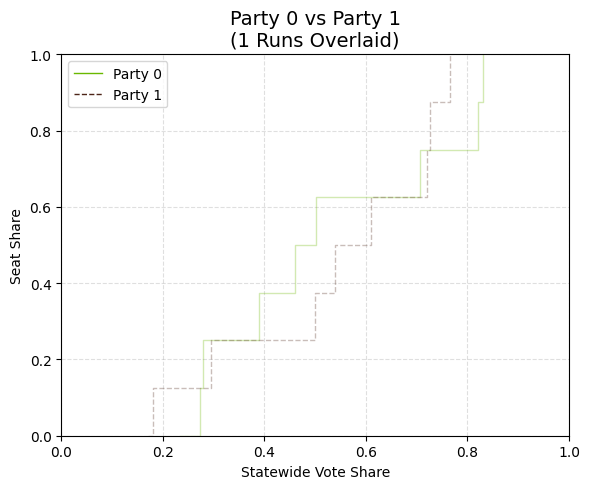

In [70]:
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_pairwise_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=20):
    """
    Creates one graph for each unique party pair.
    Each graph overlays multiple simulation runs to show the variance in bias.
    """
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    num_pairs = len(party_pairs)
    
    # Create a grid: 1 row, N columns (one for each pair)
    fig, axes = plt.subplots(1, num_pairs, figsize=(6 * num_pairs, 5), squeeze=False)
    
    # Determine how many runs to overlay
    runs_to_show = min(num_runs_to_plot, len(all_step_curves))

    for pair_idx, (party_a, party_b) in enumerate(party_pairs):
        ax = axes[0, pair_idx]
        
        for run_idx in range(runs_to_show):
            # Extract curves
            curve_a = all_step_curves[run_idx][party_a]
            curve_b = all_step_curves[run_idx][party_b]
            
            xa, ya = zip(*sorted(curve_a))
            xb, yb = zip(*sorted(curve_b))
            
            # Normalize to Seat Share
            ya_norm = np.array(ya) / NUM_DISTRICTS
            yb_norm = np.array(yb) / NUM_DISTRICTS
            
            # Use alpha (transparency) to handle the "overlay" effect
            # Only add a label for the first run so the legend isn't huge
            label_a = party_a if run_idx == 0 else None
            label_b = party_b if run_idx == 0 else None
            
            ax.step(xa, ya_norm, where='post', color=PARTY_COLORS[party_a], 
                    alpha=0.3, lw=1, label=label_a)
            ax.step(xb, yb_norm, where='post', color=PARTY_COLORS[party_b], 
                    alpha=0.3, lw=1, label=label_b, linestyle='--')

        # Formatting
        ax.set_title(f"{party_a} vs {party_b}\n({runs_to_show} Runs Overlaid)", fontsize=14)
        ax.set_xlabel("Statewide Vote Share")
        ax.set_ylabel("Seat Share")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.4)
        
        # Legend with opaque lines for clarity
        leg = ax.legend(loc='upper left')
        for lh in leg.legend_handles: 
            lh.set_alpha(1)

    plt.tight_layout()
    plt.show()

# --- Execution ---
plot_pairwise_overlays(all_step_curves, PARTY_IDS, num_runs_to_plot=1)


--- PAIRWISE AREA DIFFERENCES ---
        Comparison  Run 1  Run 2  Run 3  Run 4  Run 5  Run 6  Run 7  Run 8  Run 9  Run 10  Run 11  Run 12  Run 13  Run 14  Run 15  Run 16  Run 17  Run 18  Run 19  Run 20  Run 21  Run 22  Run 23  Run 24  Run 25  Run 26  Run 27  Run 28  Run 29  Run 30  Run 31  Run 32  Run 33  Run 34  Run 35  Run 36  Run 37  Run 38  Run 39  Run 40  Run 41  Run 42  Run 43  Run 44  Run 45  Run 46  Run 47  Run 48  Run 49  Run 50  Run 51  Run 52  Run 53  Run 54  Run 55  Run 56  Run 57  Run 58  Run 59  Run 60  Run 61  Run 62  Run 63  Run 64  Run 65  Run 66  Run 67  Run 68  Run 69  Run 70  Run 71  Run 72  Run 73  Run 74  Run 75  Run 76  Run 77  Run 78  Run 79  Run 80  Run 81  Run 82  Run 83  Run 84  Run 85  Run 86  Run 87  Run 88  Run 89  Run 90  Run 91  Run 92  Run 93  Run 94  Run 95  Run 96  Run 97  Run 98  Run 99  Run 100  Run 101  Run 102  Run 103  Run 104  Run 105  Run 106  Run 107  Run 108  Run 109  Run 110  Run 111  Run 112  Run 113  Run 114  Run 115  Run 116  Run 117  

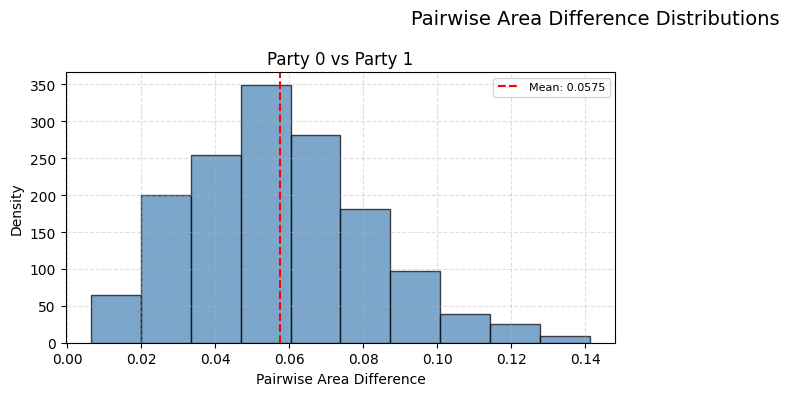

In [86]:
# ------------------------------------------------------------
# PAIRWISE AREA DIFFERENCE TABLE
# ------------------------------------------------------------
import math
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
party_pairs = list(itertools.combinations(PARTY_IDS, 2))
pairwise_matrix = []
pair_labels = []

for p1, p2 in party_pairs:
    pair_label = f"{p1} vs {p2}"
    pair_labels.append(pair_label)
    pair_row = []
    for run_idx in range(len(all_area_results)):
        area = compute_pairwise_area(
            all_step_curves[run_idx][p1],
            all_step_curves[run_idx][p2],
            NUM_DISTRICTS
        )
        pair_row.append(area)
    pairwise_matrix.append(pair_row)

df_pairwise = pd.DataFrame(
    pairwise_matrix,
    columns=[f"Run {i+1}" for i in range(len(all_area_results))]
)
df_pairwise["Mean"] = df_pairwise.mean(axis=1)
df_pairwise["Std Dev"] = df_pairwise.std(axis=1)
df_pairwise.insert(0, "Comparison", pair_labels)

print("\n--- PAIRWISE AREA DIFFERENCES ---")
print(df_pairwise.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------
# PAIRWISE HISTOGRAM
# ------------------------------------------------------------

n_pairs = len(party_pairs)
n_cols = 2
n_rows = math.ceil(n_pairs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, (p1, p2) in enumerate(party_pairs):
    data = list(df_pairwise.iloc[i, 1:len(all_area_results)+1])
    mean_val = np.mean(data)

    axes[i].hist(data, bins=min(10, len(data)), alpha=0.7,
                 color='steelblue', edgecolor='black', density=False)
    axes[i].axvline(mean_val, color='red', linestyle='--',
                    linewidth=1.5, label=f"Mean: {mean_val:.4f}")
    axes[i].set_title(f"{p1} vs {p2}", fontsize=12)
    axes[i].set_xlabel("Pairwise Area Difference")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, linestyle="--", alpha=0.4)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Pairwise Area Difference Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [72]:
def print_election_results(all_district_counts, all_pr_vote_shares, all_pr_seat_shares, PARTY_IDS, NUM_DISTRICTS):
    """
    Prints a detailed election breakdown for each run including:
      - District-level vote counts and winner
      - Total seats won per party
      - Statewide vote share per party
    """
    for run_idx, district_counts in enumerate(all_district_counts):
        print(f"\n{'='*60}")
        print(f"  RUN {run_idx + 1}")
        print(f"{'='*60}")

        # District breakdown
        print(f"\n  {'District':<12} {'Winner':<12}", end="")
        for party in PARTY_IDS:
            print(f" {party:>12}", end="")
        print(f" {'Total':>10}")
        print(f"  {'-'*12} {'-'*12}", end="")
        for _ in PARTY_IDS:
            print(f" {'-'*12}", end="")
        print(f" {'-'*10}")

        for d_idx, counts in enumerate(district_counts):
            winner = max(counts, key=counts.get)
            total = sum(counts.values())
            print(f"  {'District '+str(d_idx+1):<12} {winner:<12}", end="")
            for party in PARTY_IDS:
                print(f" {counts[party]:>12}", end="")
            print(f" {total:>10}")

        # Seats won per party
        seats = {party: 0 for party in PARTY_IDS}
        for counts in district_counts:
            winner = max(counts, key=counts.get)
            seats[winner] += 1

        print(f"\n  {'--- Seats Won ---'}")
        for party in PARTY_IDS:
            bar = "█" * seats[party]
            print(f"  {party:<12}: {seats[party]:>2} seats  {bar}")

        # Statewide vote share
        print(f"\n  {'--- Statewide Vote Share ---'}")
        for party in PARTY_IDS:
            vote_share = all_pr_vote_shares[run_idx][party]
            seat_share = all_pr_seat_shares[run_idx][party]
            print(f"  {party:<12}: Vote {vote_share:.3f}  |  Seat Share {seat_share:.3f}")

    print(f"\n{'='*60}")
    print("  END OF RESULTS")
    print(f"{'='*60}\n")


# ── USAGE — call this after the simulation loop ──
print_election_results(all_district_counts, all_pr_vote_shares, all_pr_seat_shares, PARTY_IDS, NUM_DISTRICTS)


  RUN 1

  District     Winner            Party 0      Party 1      Total
  ------------ ------------ ------------ ------------ ----------
  District 1   Party 1                37           88        125
  District 2   Party 0                95           30        125
  District 3   Party 1                16          109        125
  District 4   Party 0               102           23        125
  District 5   Party 1                14          111        125
  District 6   Party 0                94           31        125
  District 7   Party 0                76           49        125
  District 8   Party 0                67           58        125

  --- Seats Won ---
  Party 0     :  5 seats  █████
  Party 1     :  3 seats  ███

  --- Statewide Vote Share ---
  Party 0     : Vote 0.501  |  Seat Share 0.625
  Party 1     : Vote 0.499  |  Seat Share 0.375

  RUN 2

  District     Winner            Party 0      Party 1      Total
  ------------ ------------ ------------ ------------ 


--- FAIR: EFFICIENCY GAP ---
 Run  Efficiency_Gap  Party 0_Wasted  Party 1_Wasted
   1          0.0154          0.3050          0.4290
   2          0.0000          0.3580          0.3550
   3          0.0154          0.3030          0.4270
   4          0.0154          0.3060          0.4300
   5          0.0154          0.3030          0.4270
   6          0.0154          0.3040          0.4280
   7          0.0000          0.3710          0.3680
   8          0.0000          0.3650          0.3620
   9          0.0154          0.2940          0.4180
  10          0.0000          0.3690          0.3660
  11          0.0154          0.2810          0.4050
  12          0.0000          0.3670          0.3640
  13          0.0154          0.3020          0.4260
  14          0.0000          0.3690          0.3660
  15          0.0154          0.3020          0.4260
  16          0.0154          0.2970          0.4210
  17          0.0000          0.3720          0.3690
  18          0.

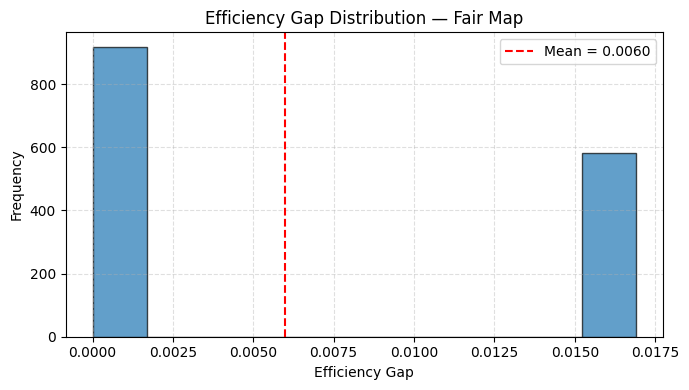

In [78]:
# ============================================================
# MULTI-PARTY EFFICIENCY GAP — SUM OF SQUARED DIFFERENCES
# ============================================================

gap_rows=[]

def compute_efficiency_gap_table(all_district_counts, label=""):


    for run_idx in range(len(all_district_counts)):
        district_counts = all_district_counts[run_idx]

        wasted_votes = {party: 0 for party in PARTY_IDS}
        total_votes  = 0

        for district in district_counts:
            district_total  = sum(district.values())
            total_votes    += district_total

            sorted_parties  = sorted(district.items(), key=lambda x: x[1], reverse=True)
            winner, _       = sorted_parties[0]
            runner_up_votes = sorted_parties[1][1] if len(sorted_parties) > 1 else 0
            needed_to_win   = runner_up_votes + 1

            for party in PARTY_IDS:
                votes = district[party]
                if party == winner:
                    wasted_votes[party] += max(0, votes - needed_to_win)
                else:
                    wasted_votes[party] += votes

        w = {party: wasted_votes[party] / total_votes for party in PARTY_IDS}

        squared_diff_sum = 0.0
        for p1, p2 in itertools.combinations(PARTY_IDS, 2):
            squared_diff_sum += (w[p1] - w[p2]) ** 2

        gap_rows.append({
            "Run":            run_idx + 1,
            "Efficiency_Gap": squared_diff_sum,
            **{f"{party}_Wasted": w[party] for party in PARTY_IDS}
        })

    df_gap = pd.DataFrame(gap_rows)

    print(f"\n--- {label}: EFFICIENCY GAP ---")
    print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print(f"\nMean Efficiency Gap: {df_gap['Efficiency_Gap'].mean():.4f}")
    print(f"Std  Efficiency Gap: {df_gap['Efficiency_Gap'].std():.4f}")

    return df_gap

df_gap = compute_efficiency_gap_table(all_district_counts, label="FAIR")

# ── Histogram ─────────────────────────────────────────────
data     = df_gap["Efficiency_Gap"].values
mean_val = np.mean(data)

plt.figure(figsize=(7, 4))
plt.hist(data, bins=10, alpha=0.7, edgecolor="black")
plt.axvline(mean_val, color="red", linestyle="--",
            label=f"Mean = {mean_val:.4f}")
plt.title("Efficiency Gap Distribution — Fair Map")
plt.xlabel("Efficiency Gap")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

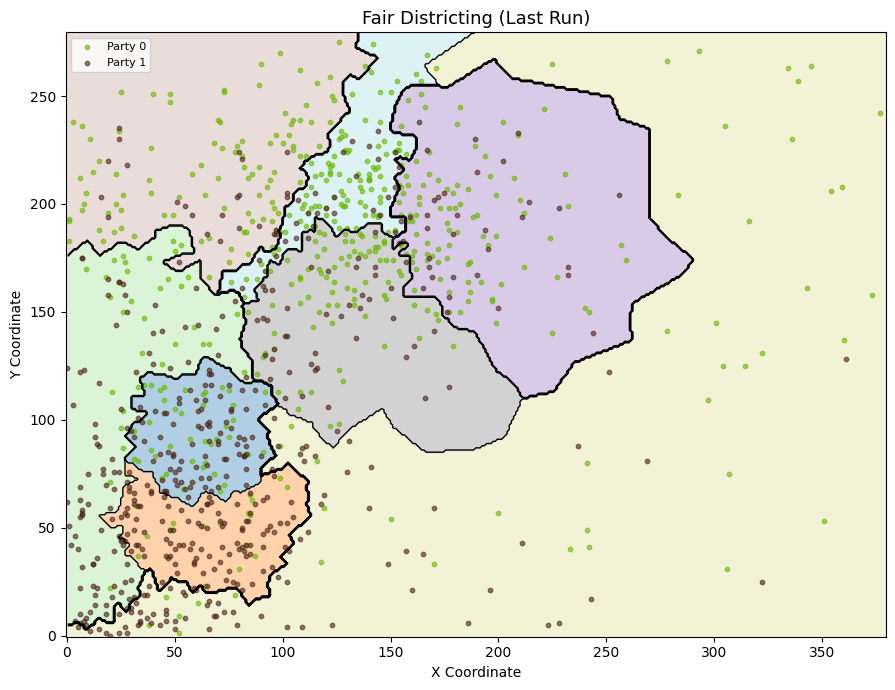

In [74]:

# ============================================================
# VISUALIZATION
# ============================================================
def plot_districts(district_labels, voter_parties, title):
    tree = cKDTree(voters)
    xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
    grid_points = np.column_stack((xx.ravel(), yy.ravel()))
    _, nearest_voter = tree.query(grid_points)
    pixel_map = district_labels[nearest_voter].reshape((HEIGHT, WIDTH))

    plt.figure(figsize=(10, 7))
    plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)
    plt.contour(pixel_map, levels=np.arange(NUM_DISTRICTS) + 0.5,
                colors='black', linewidths=1, origin='lower')
    for i, party in enumerate(PARTY_IDS):
        mask = voter_parties == i
        plt.scatter(voters[mask, 0], voters[mask, 1],
                    color=PARTY_COLORS[party], label=party, s=10, alpha=0.6)
    plt.title(title, fontsize=13)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# ============================================================
# VISUALIZE LAST RUN
# ============================================================
plot_districts(district_labels, voter_parties, "Fair Districting (Last Run)")

In [75]:
for i, party in enumerate(PARTY_IDS):
    print(f"{party} center: x={party_centers[i,0]:.1f}, y={party_centers[i,1]:.1f}")
for i, party in enumerate(PARTY_IDS):
    print(f"{party}: {np.sum(voter_parties == i)} voters")

Party 0 center: x=255.5, y=231.1
Party 1 center: x=185.5, y=8.8
Party 0: 501 voters
Party 1: 499 voters


In [82]:
df_gap.to_csv(f"efficiency_gap_random_{NUM_PARTIES}.csv", index=False)
df_gap.to_csv(f"pairwise_random_{NUM_PARTIES}.csv", index=False)

In [76]:
# ------------------------
# DISTRICT WINNERS PER RUN
# ------------------------
winner_rows = []

for run_idx in range(NUM_RUNS):
    gerry_row = {"Run": run_idx + 1}
    for d_idx, gc in enumerate(all_district_counts[run_idx]):
        gerry_row[f"District {d_idx + 1}"] = max(gc, key=gc.get)
    winner_rows.append(gerry_row)

df_winners = pd.DataFrame(winner_rows)

print("\n--- GERRYMANDERED MAP: District Winners per Run ---")
print(df_winners.to_string(index=False))


--- GERRYMANDERED MAP: District Winners per Run ---
 Run District 1 District 2 District 3 District 4 District 5 District 6 District 7 District 8
   1    Party 1    Party 0    Party 1    Party 0    Party 1    Party 0    Party 0    Party 0
   2    Party 0    Party 0    Party 1    Party 0    Party 1    Party 1    Party 0    Party 1
   3    Party 0    Party 1    Party 1    Party 0    Party 1    Party 0    Party 0    Party 0
   4    Party 0    Party 0    Party 1    Party 1    Party 1    Party 0    Party 0    Party 0
   5    Party 0    Party 1    Party 0    Party 0    Party 0    Party 1    Party 0    Party 1
   6    Party 0    Party 0    Party 0    Party 0    Party 1    Party 1    Party 1    Party 0
   7    Party 1    Party 1    Party 0    Party 1    Party 0    Party 1    Party 0    Party 0
   8    Party 0    Party 0    Party 1    Party 0    Party 1    Party 1    Party 0    Party 1
   9    Party 0    Party 0    Party 1    Party 0    Party 0    Party 1    Party 0    Party 1
  10    Party 0  

In [77]:
def export_pairwise_summary_csv(all_step_curves, PARTY_IDS, NUM_DISTRICTS, filename):
    """
    Exports pairwise summary (Mean, Std Dev) — used for the random baseline.
    """
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))

    pair_data = {f"{p1} vs {p2}": [] for p1, p2 in party_pairs}

    for run_idx, curves in enumerate(all_step_curves):
        for p1, p2 in party_pairs:
            area = compute_pairwise_area(curves[p1], curves[p2], NUM_DISTRICTS)
            pair_data[f"{p1} vs {p2}"].append(area)

    rows = []
    for comparison, values in pair_data.items():
        rows.append({
            "Comparison": comparison,
            "Mean":       round(np.mean(values), 6),
            "Std Dev":    round(np.std(values), 6)
        })

    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")
    return df

       # ── Call at the end of your fair map script ──────────────────
export_pairwise_summary_csv(
    all_step_curves, PARTY_IDS, NUM_DISTRICTS,
    filename="pairwise_random.csv"
)

Saved: pairwise_random.csv


,Comparison,Mean,Std Dev
0,Party 0 vs Party 1,0.057472,0.024283


In [84]:
import pandas as pd

df_pair = pd.read_csv("pairwise_random_2.csv")
df_eff  = pd.read_csv("efficiency_gap_random_2.csv")

print("PAIRWISE COLUMNS:")
print(df_pair.columns.tolist())
print("\nPAIRWISE HEAD:")
print(df_pair.head())

print("\nEFFICIENCY GAP COLUMNS:")
print(df_eff.columns.tolist())
print("\nEFFICIENCY GAP HEAD:")
print(df_eff.head())

PAIRWISE COLUMNS:
['Run', 'Efficiency_Gap', 'Party 0_Wasted', 'Party 1_Wasted']

PAIRWISE HEAD:
   Run  Efficiency_Gap  Party 0_Wasted  Party 1_Wasted
0    1        0.015376           0.305           0.429
1    2        0.000009           0.358           0.355
2    3        0.015376           0.303           0.427
3    4        0.015376           0.306           0.430
4    5        0.015376           0.303           0.427

EFFICIENCY GAP COLUMNS:
['Run', 'Efficiency_Gap', 'Party 0_Wasted', 'Party 1_Wasted']

EFFICIENCY GAP HEAD:
   Run  Efficiency_Gap  Party 0_Wasted  Party 1_Wasted
0    1        0.015376           0.305           0.429
1    2        0.000009           0.358           0.355
2    3        0.015376           0.303           0.427
3    4        0.015376           0.306           0.430
4    5        0.015376           0.303           0.427
